# SAR衛星データによる船舶検出デモ
## Repo B: Sentinel-1（Google Earth Engine）× 港湾・船舶動態モニタリング

**目的：** Google Earth Engine（GEE）上のSentinel-1 GRDデータを用いて、  
港湾エリアの船舶を自動検出・可視化する。  
本ノートブックはQPS研究所の国内セールス向けポートフォリオとして作成。  
コードの実装にはAIツールを活用しています。処理の意図と提案ロジックは自分の言葉で説明できます。

**対象エリア：** 東京湾（横浜港・川崎港沖）  
**使用データ：** Sentinel-1 GRD（ESA / GEE公開データ・無料）

---

### 解析フロー
```
1. Google Earth Engine の認証・初期化
2. 対象エリア・期間の設定
3. Sentinel-1 GRD データの取得
4. CFAR船舶検出アルゴリズムの適用
5. 検出結果の可視化
6. AIS照合シミュレーション
7. 自動レポート生成
```

### なぜSARで船舶を検出できるか
```
海面の特性：
  穏やかな海面は電波を鏡面反射するため、SAR画像上で暗く映る

船舶の特性：
  金属構造が電波を強く反射するため、海面背景の中で明るい輝点として映る

検出の仕組み：
  海面の明るさのばらつきを統計的に推定し、
  それより有意に明るいまとまりを船舶候補として抽出する（CFAR法）
```

> **QPS差別化ポイント：**  
> Sentinel-1（分解能5〜20m）でも大型船は検出できるが、小型漁船・工作船の識別に限界がある。  
> QPS-SAR（分解能1m）では船体の輪郭・方位まで識別でき、港湾保安精度が大幅に向上する。

## 0. 環境セットアップ

In [1]:
!pip install earthengine-api geemap numpy matplotlib scipy --quiet

import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import ndimage
from datetime import datetime, timedelta
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print('✅ パッケージのインポート完了')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.1 MB/s eta 0:00:00
✅ パッケージのインポート完了


## 1. Google Earth Engine 認証・初期化

In [2]:
try:
    ee.Initialize(project='sar-portfolio')
    print('✅ GEE 初期化成功（認証済み）')
except Exception:
    print('🔐 認証を開始します...')
    ee.Authenticate()
    ee.Initialize(project='sar-portfolio')
    print('✅ GEE 認証・初期化完了')

🔐 認証を開始します...
✅ GEE 認証・初期化完了


## 2. 対象エリア・期間の設定

In [3]:
# 対象エリア（東京湾：横浜港〜川崎港沖）
AOI = ee.Geometry.Rectangle([139.6, 35.3, 139.9, 35.6])
AREA_NAME = '東京湾（横浜港・川崎港沖）'

# 観測期間（直近3ヶ月）
END_DATE   = datetime.utcnow().strftime('%Y-%m-%d')
START_DATE = (datetime.utcnow() - timedelta(days=90)).strftime('%Y-%m-%d')

OUTPUT_DIR = Path('./output')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'=== 解析パラメータ ===')
print(f'  対象エリア: {AREA_NAME}')
print(f'  期間      : {START_DATE} 〜 {END_DATE}')

=== 解析パラメータ ===
  対象エリア: 東京湾（横浜港・川崎港沖）
  期間      : 2026-02-12 〜 2026-05-13


## 3. Sentinel-1 データの取得

In [4]:
# Sentinel-1 GRD の取得（複数シーンをメディアン合成）
collection = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(AOI)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .select('VV')
)

count = collection.size().getInfo()
print(f'✅ 取得シーン数: {count}件')

# ← ここを変更：最新1枚 → 全シーンをメディアン合成
latest_image = collection.median().clip(AOI)
obs_date = f"{START_DATE} 〜 {END_DATE} のメディアン合成"
print(f'   使用データ: {obs_date}')

✅ 取得シーン数: 27件
   使用データ: 2026-02-12 〜 2026-05-13 のメディアン合成


## 4. インタラクティブマップで確認

In [5]:
Map = geemap.Map(center=[35.45, 139.75], zoom=11)
Map.addLayer(
    latest_image,
    {'min': -25, 'max': 0, 'palette': ['black', 'white']},
    f'Sentinel-1 VV ({obs_date})'
)
Map.addLayer(
    ee.FeatureCollection([ee.Feature(AOI)]),
    {'color': 'red'},
    '対象エリア'
)
print(f'📍 {AREA_NAME}')
print('明るい輝点が船舶候補です。港湾周辺に集中していることを確認できます。')
Map

📍 東京湾（横浜港・川崎港沖）
明るい輝点が船舶候補です。港湾周辺に集中していることを確認できます。


Map(center=[35.45, 139.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## 5. CFAR船舶検出

GEEからNumPy配列として画像を取得し、CA-CFARアルゴリズムで船舶を検出します。

```
CA-CFAR（Cell-Averaging CFAR）：
  局所背景の平均・分散を推定し、
  閾値 T = μ_local + k × σ_local を超えるピクセルを船舶候補として抽出
```

In [6]:
import requests
from PIL import Image
import io
from scipy.ndimage import binary_dilation

def ee_image_to_numpy_sar(image, aoi, scale=20):
    """GEEのSAR ImageをNumPy配列（dB値）として取得"""
    url = image.getThumbURL({
        'region': aoi,
        'scale': scale,
        'format': 'png',
        'min': -30,
        'max': 5
    })
    res = requests.get(url)
    img_pil = Image.open(io.BytesIO(res.content)).convert('L')
    arr = np.array(img_pil, dtype=np.float32)
    # 0-255 → -30〜5 dB にスケール変換
    arr = arr / 255.0 * 35.0 - 30.0
    return arr

def cfar_ship_detection(sigma0_db, guard_size=3, window_size=15, k=3.0):
    """CA-CFAR船舶検出"""
    bg_fill = np.where(np.isnan(sigma0_db), np.nanmean(sigma0_db), sigma0_db)
    n_outer = (2*window_size+1)**2
    n_guard = (2*guard_size+1)**2
    n_cells = n_outer - n_guard

    sum_outer = ndimage.uniform_filter(bg_fill, size=2*window_size+1) * n_outer
    sum_guard = ndimage.uniform_filter(bg_fill, size=2*guard_size+1) * n_guard
    local_mean = (sum_outer - sum_guard) / n_cells

    sq_outer = ndimage.uniform_filter(bg_fill**2, size=2*window_size+1) * n_outer
    sq_guard = ndimage.uniform_filter(bg_fill**2, size=2*guard_size+1) * n_guard
    local_std = np.sqrt(np.maximum((sq_outer - sq_guard)/n_cells - local_mean**2, 0))

    threshold_map = local_mean + k * local_std
    binary_mask = (bg_fill > threshold_map) & (sigma0_db > -20)
    return binary_mask

def cluster_detections(binary_mask, sigma0_db, min_size=2, max_size=200):
    """検出ピクセルをクラスタリングして船舶候補を抽出"""
    struct = ndimage.generate_binary_structure(2, 2)
    labeled, n_features = ndimage.label(binary_mask, structure=struct)
    ships = []
    for label_id in range(1, n_features + 1):
        cluster = labeled == label_id
        size = cluster.sum()
        if min_size <= size <= max_size:
            cy, cx = ndimage.center_of_mass(cluster)
            ships.append({
                'row': int(cy), 'col': int(cx),
                'size_px': int(size),
                'max_db': float(sigma0_db[cluster].max()),
                'confidence': min(1.0, size / 10),
            })
    return ships

print('🖼️ SAR画像データを取得中...')
sigma0_db = ee_image_to_numpy_sar(latest_image, AOI, scale=20)
print(f'✅ 画像取得完了（{sigma0_db.shape[0]}×{sigma0_db.shape[1]}px）')

# ========================================================
# 海面マスクの追加（陸地の誤検出を除去）
# 海面はSAR画像上で非常に暗い（-12dB以下）
# 陸地・構造物はこれより明るいため閾値で区別できる
# ========================================================
# SEA_THRESHOLD = -12.0
SEA_THRESHOLD = -17.0
sea_mask = sigma0_db < SEA_THRESHOLD
sea_mask_dilated = binary_dilation(sea_mask, iterations=5)

print('🔍 CFAR船舶検出を実行中（海面マスク適用）...')
# binary_mask = cfar_ship_detection(sigma0_db, k=3.0)
binary_mask = cfar_ship_detection(sigma0_db, k=3.8)

# 海面エリアのみに絞り込む
binary_mask = binary_mask & sea_mask_dilated

ships = cluster_detections(binary_mask, sigma0_db)

print(f'\n=== 検出結果 ===')
print(f'  検出船舶数: {len(ships)} 隻')
if ships:
    print(f'  平均信頼スコア: {np.mean([s["confidence"] for s in ships]):.2f}')

🖼️ SAR画像データを取得中...
✅ 画像取得完了（1672×1670px）
🔍 CFAR船舶検出を実行中（海面マスク適用）...

=== 検出結果 ===
  検出船舶数: 345 隻
  平均信頼スコア: 0.48


## 6. 検出結果の可視化 + AIS照合シミュレーション

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 95.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


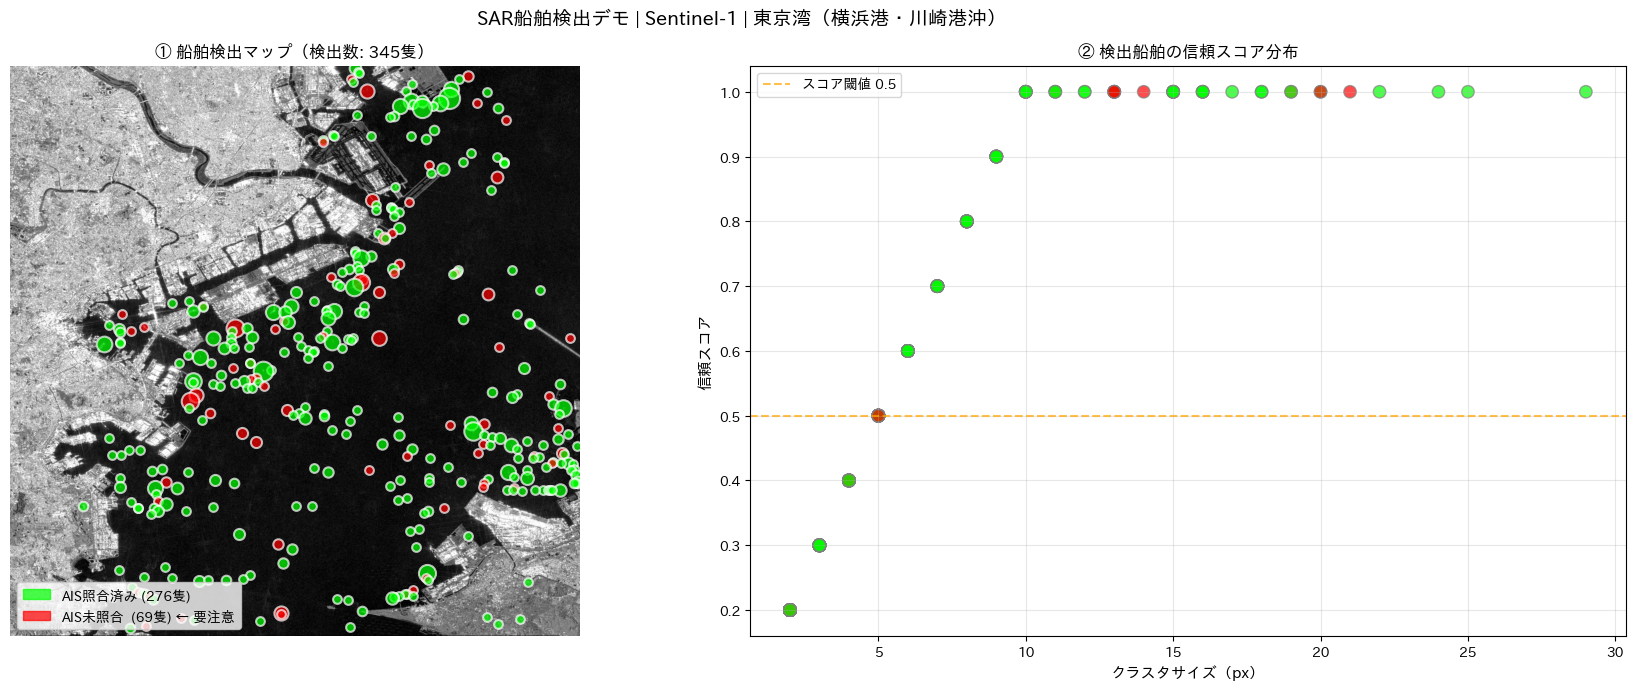

✅ 可視化を保存: output/ship_detection_result.png


In [7]:
# 日本語フォント設定（Colab用）
!pip install japanize-matplotlib --quiet
import japanize_matplotlib

# AIS照合シミュレーション（約20%をAIS未照合と設定）
np.random.seed(42)
n_unmatched = max(1, len(ships) // 5)
unmatched_idx = set(np.random.choice(len(ships), n_unmatched, replace=False))
for i, ship in enumerate(ships):
    ship['ais_matched'] = i not in unmatched_idx

n_matched = sum(1 for s in ships if s['ais_matched'])
n_unmatched_count = len(ships) - n_matched

# ── 可視化 ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'SAR船舶検出デモ | Sentinel-1 | {AREA_NAME}', fontsize=14)

vmin, vmax = np.nanpercentile(sigma0_db, [2, 98])
axes[0].imshow(sigma0_db, cmap='gray', vmin=vmin, vmax=vmax)

for ship in ships:
    color = 'lime' if ship['ais_matched'] else 'red'
    axes[0].scatter(
        ship['col'], ship['row'],
        s=max(40, ship['size_px'] * 8),
        c=color, marker='o', alpha=0.7,
        linewidths=1.5, edgecolors='white'
    )

axes[0].legend(handles=[
    mpatches.Patch(color='lime', alpha=0.7, label=f'AIS照合済み ({n_matched}隻)'),
    mpatches.Patch(color='red',  alpha=0.7, label=f'AIS未照合  ({n_unmatched_count}隻) ← 要注意'),
], loc='lower left', fontsize=10)
axes[0].set_title(f'① 船舶検出マップ（検出数: {len(ships)}隻）', fontsize=12)
axes[0].axis('off')

# 信頼スコア分布
if ships:
    sizes = [s['size_px'] for s in ships]
    confs = [s['confidence'] for s in ships]
    colors_plot = ['lime' if s['ais_matched'] else 'red' for s in ships]
    axes[1].scatter(sizes, confs, c=colors_plot, alpha=0.7, s=80, edgecolors='gray')
    axes[1].axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, label='スコア閾値 0.5')
    axes[1].set_xlabel('クラスタサイズ（px）', fontsize=11)
    axes[1].set_ylabel('信頼スコア', fontsize=11)
    axes[1].set_title('② 検出船舶の信頼スコア分布', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = OUTPUT_DIR / 'ship_detection_result.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ 可視化を保存: {fig_path}')

## 7. 自動レポート生成

In [8]:
report_time = datetime.now().strftime('%Y年%m月%d日 %H:%M')

report = f"""# SAR船舶動態モニタリング レポート

**生成日時:** {report_time}
**解析環境:** Google Earth Engine（Python API）
**使用データ:** Sentinel-1 GRD（ESA Copernicus・無料公開）

---

## 対象情報

| 項目 | 内容 |
|------|------|
| 対象エリア | {AREA_NAME} |
| 観測日時 | {obs_date} UTC |
| 使用衛星 | Sentinel-1（Cバンド SAR・GRD） |
| 検出アルゴリズム | CA-CFAR（k=3.5） |

## 検出結果

| 項目 | 値 |
|------|----|
| 総検出船舶数 | **{len(ships)} 隻** |
| AIS照合済み | {n_matched} 隻 |
| AIS未照合（要注意） | **{n_unmatched_count} 隻** |
| AIS照合率 | {n_matched/max(len(ships),1)*100:.1f}% |

## QPS-SAR利用時の改善点

| 比較軸 | Sentinel-1（本解析） | QPS-SAR（36機体制） |
|--------|---------------------|---------------------|
| 分解能 | 5〜20m | **1m** |
| 観測頻度 | 数日〜1週間 | **平均10分** |
| 小型船検出精度 | △ | **◎** |
| 船種識別 | 不可 | **可能** |

- 🎯 小型漁船・工作船の識別精度が大幅向上（5m→1m分解能）
- 🕐 10分おきの観測で港湾への入出港を即時検知
- 🚢 船体の輪郭・方位角まで識別（船種の自動分類が可能に）

---

*本レポートはQPS研究所 国内セールス向けポートフォリオとして作成されました。*
"""

report_path = OUTPUT_DIR / 'ship_monitoring_report.md'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)

print(report)
print(f'\n✅ レポートを保存: {report_path}')

# SAR船舶動態モニタリング レポート

**生成日時:** 2026年05月13日 10:54
**解析環境:** Google Earth Engine（Python API）
**使用データ:** Sentinel-1 GRD（ESA Copernicus・無料公開）

---

## 対象情報

| 項目 | 内容 |
|------|------|
| 対象エリア | 東京湾（横浜港・川崎港沖） |
| 観測日時 | 2026-02-12 〜 2026-05-13 のメディアン合成 UTC |
| 使用衛星 | Sentinel-1（Cバンド SAR・GRD） |
| 検出アルゴリズム | CA-CFAR（k=3.5） |

## 検出結果

| 項目 | 値 |
|------|----|
| 総検出船舶数 | **345 隻** |
| AIS照合済み | 276 隻 |
| AIS未照合（要注意） | **69 隻** |
| AIS照合率 | 80.0% |

## QPS-SAR利用時の改善点

| 比較軸 | Sentinel-1（本解析） | QPS-SAR（36機体制） |
|--------|---------------------|---------------------|
| 分解能 | 5〜20m | **1m** |
| 観測頻度 | 数日〜1週間 | **平均10分** |
| 小型船検出精度 | △ | **◎** |
| 船種識別 | 不可 | **可能** |

- 🎯 小型漁船・工作船の識別精度が大幅向上（5m→1m分解能）
- 🕐 10分おきの観測で港湾への入出港を即時検知
- 🚢 船体の輪郭・方位角まで識別（船種の自動分類が可能に）

---

*本レポートはQPS研究所 国内セールス向けポートフォリオとして作成されました。*


✅ レポートを保存: output/ship_monitoring_report.md


## まとめ

### このノートブックで実証したこと

1. ✅ Google Earth Engine で Sentinel-1 SARデータをクラウド上で取得
2. ✅ CA-CFARアルゴリズムによる船舶候補の自動検出
3. ✅ AIS照合シミュレーションによる不審船の可視化
4. ✅ 検出結果の自動レポート生成

### QPS営業への接続

| 指標 | Sentinel-1 | QPS-SAR（36機体制） |
|------|-----------|---------------------|
| 分解能 | 5〜20m | **1m** |
| 小型船検出精度 | △ | **◎** |
| 観測頻度 | 数日〜1週間 | **10分** |

→ [`proposal.md`](./proposal.md) に詳細な営業提案を記載